## Examining Distributions: Skewness

One important step in analyzing numerical variables is examining their distributions.  
In many real datasets, values are not distributed symmetrically, but are shifted in one direction.

In the Diamonds dataset, several numerical variables are **right-skewed**.  
This means that most observations are concentrated around smaller values, while a few large values create a long "tail" on the right side of the distribution.

This matters because strongly skewed distributions:

- are harder to interpret,
- can make the analysis more sensitive to outliers,
- may reduce the effectiveness of certain models and statistical methods,
- and can also distort visualizations.

That is why we first examine the distributions of the main numerical variables, and later apply transformations that can move them closer to a more symmetric shape.

## A Brief Introduction to the Diamonds Dataset

The Diamonds dataset contains the characteristics and prices of different diamonds.  
Each row represents one diamond, while the columns describe its main properties, such as:

- carat: the weight of the diamond,
- cut: the quality of the cut,
- color: the color grade,
- clarity: the clarity,
- depth, 	able: proportion-related characteristics,
- x, y, z: the dimensions of the diamond,
- price: the price.

This dataset is especially useful for exploratory data analysis because:
- it contains both **numerical** and **categorical** variables,
- it is well suited for studying **distributions**,
- it allows us to search for **outliers**,
- we can analyze **relationships** between variables,
- and it is a good example for showing which factors may be related to **price**.

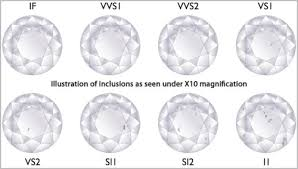

### Loading the Data

In [31]:
# Import the libraries used in this notebook
import pandas as pd
import json
import urllib.request

# Create a direct download link from the shared Google Drive link
csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

# Load the intentionally "messy" Diamonds CSV file
# Each row represents one diamond, but the dataset intentionally contains errors,
# so we can practice the steps of EDA and data cleaning
df = pd.read_csv(csv_url)

# Display the first 5 rows of the data
# This helps us quickly understand what one observation looks like
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Visualizing the Distributions of Numerical Variables

First, we select the numerical columns and then use histograms to inspect
how the values of each variable are distributed.

A histogram helps us quickly recognize whether a variable is:

- approximately symmetric,
- right-skewed or left-skewed,
- possibly multimodal,
- or whether it may contain outliers.

In [32]:
# Select the numeric columns
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')

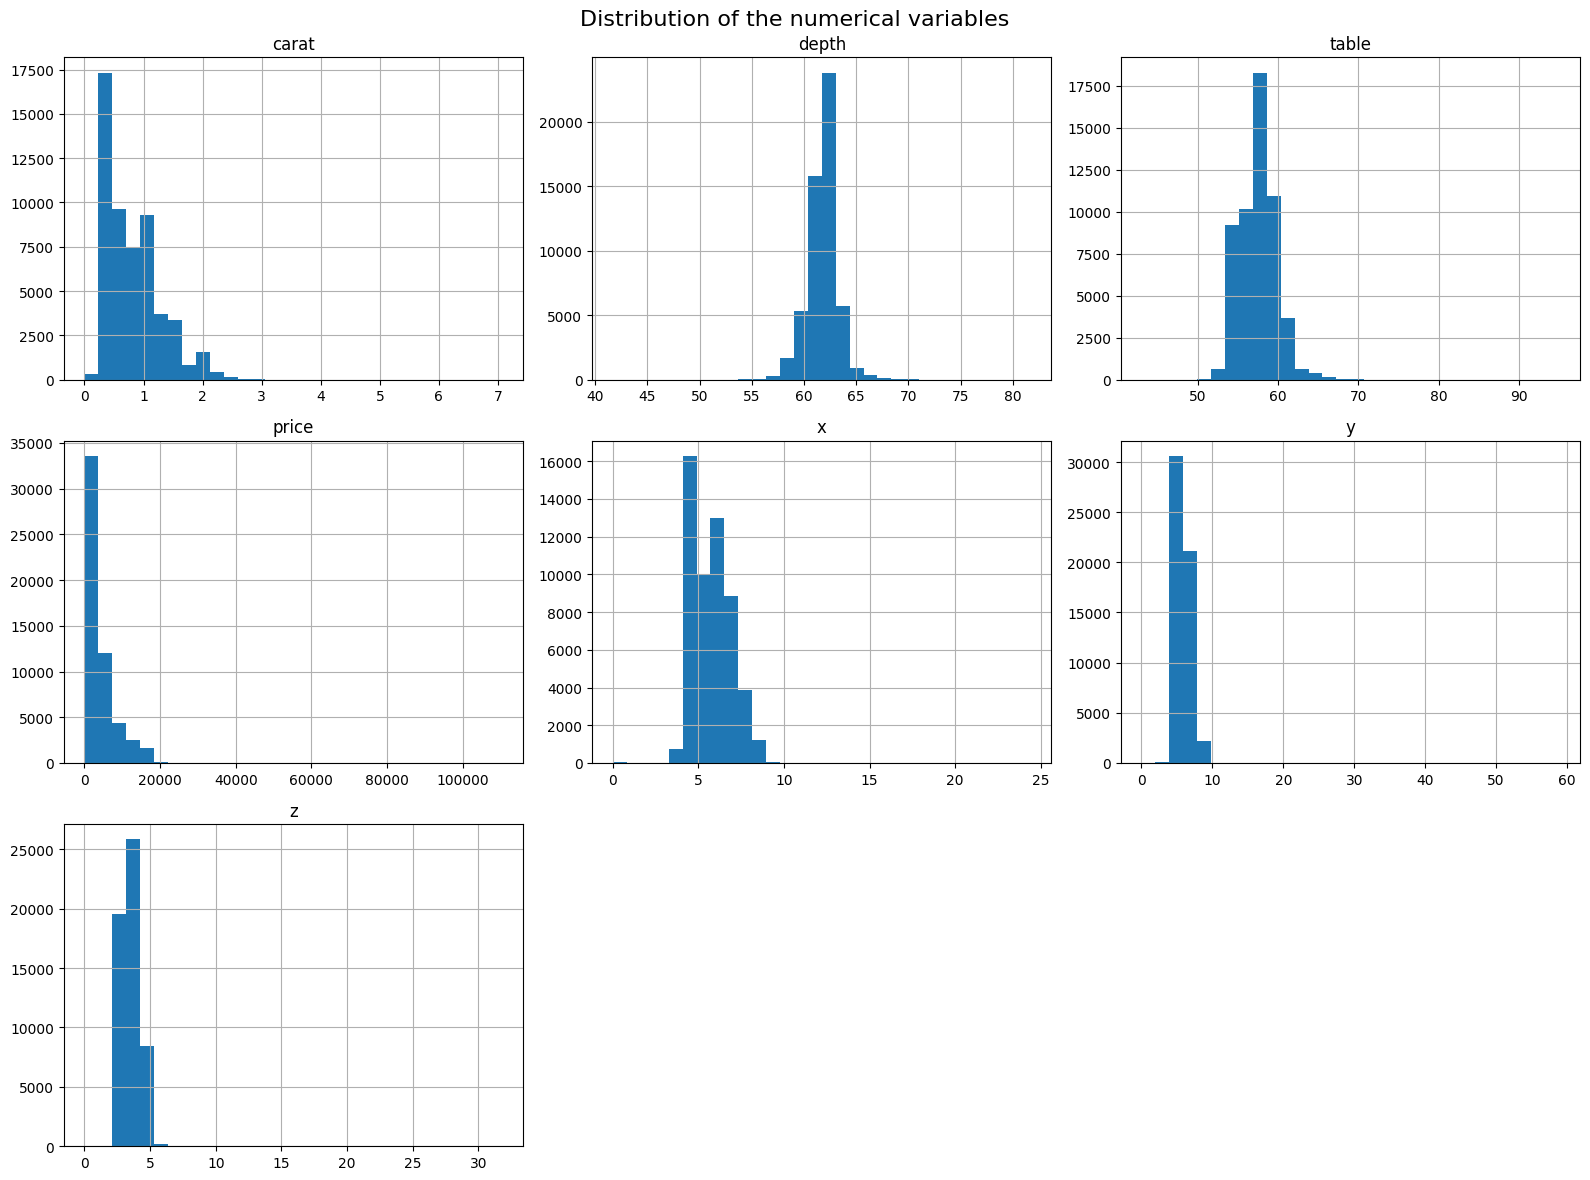

In [33]:
import matplotlib.pyplot as plt
# Plot the distributions of the numerical variables with histograms
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of the numerical variables", fontsize=16)
plt.tight_layout()
plt.show()

## What Do We See in the Plots?

Based on the plots, the distributions of several numerical variables are not symmetric, but right-skewed.

This means that:

- many observations are concentrated at smaller values,
- while a few very large values also occur,
- so the right side of the distribution stretches out more strongly.

This is especially common for variables such as `price`, `carat`, or some of the size variables, where most diamonds have smaller or medium values, and only a few are truly large or expensive.

These distributions are problematic because large values can have a disproportionately strong effect on the mean, the standard deviation, and several analysis or modeling methods.

In the next step, we will also examine this numerically using **skewness**.

In [34]:
# Calculate the skewness of the numerical variables
skewness_values = df[numeric_cols].skew().sort_values(ascending=False)

skewness_values

,0
y,2.989612
z,2.693312
price,2.458854
carat,1.419988
x,1.226675
table,0.908998
depth,-0.097000


## Measuring Skewness Numerically

Skewness shows how asymmetric a distribution is.

General interpretation:

- **value close to 0** -> approximately symmetric distribution
- **positive value** -> right-skewed distribution
- **negative value** -> left-skewed distribution

The larger the absolute value of skewness, the more distorted the distribution is.

## Artificial Examples for Understanding Skewness and Transformations

Before examining skewness on a real dataset, it is useful to look at artificially generated examples to see how different transformations affect the shape of a distribution.

The goal here is not necessarily to obtain a "perfectly normal" distribution in every case, but to understand:

- what a right-skewed or left-skewed distribution looks like,
- how each transformation changes the shape,
- and when transformations such as the logarithm, square root, squaring, or an exponential transformation may be useful.

In the examples below, we generate artificial data and compare the original and transformed versions.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## Helper Function for Comparing Distributions

To make the comparison easier, we create a simple helper function that plots the distributions of the original and transformed variables side by side.

In [36]:
def plot_original_vs_transformed(original, transformed, original_title, transformed_title):
    # Create a figure with 1 row and 2 columns.
    # The first axis shows the original variable, the second shows the transformed one.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot the histogram of the original variable.
    # - bins=30: split the values into 30 bins
    # - kde=True: also draw a smoothed density curve above the histogram,
    #   so the shape of the distribution is easier to interpret visually
    # - ax=axes[0]: draw this plot on the left panel
    sns.histplot(original, bins=30, kde=True, ax=axes[0])

    # Add a title to the left plot,
    # so it is clear that this is the distribution of the original variable
    axes[0].set_title(original_title)

    # Plot the histogram of the transformed variable with the same settings.
    # This allows the original and transformed distributions to be compared directly.
    sns.histplot(transformed, bins=30, kde=True, ax=axes[1])

    # Add a title to the right plot,
    # so it is clear which transformed distribution we see
    axes[1].set_title(transformed_title)

    # Automatically adjust the layout,
    # so the titles and axes do not overlap
    plt.tight_layout()

    # Display the figure
    plt.show()

## 1. Right-Skewed Distribution and Logarithmic Transformation

In right-skewed distributions, most values are relatively small, but a few very large values create a long tail on the right.

In such cases, a **logarithmic transformation** is often useful because it:

- compresses large values,
- reduces the effect of outliers,
- and in many cases makes the distribution more symmetric.

Now we generate a strongly right-skewed artificial distribution and then apply a logarithm to it.

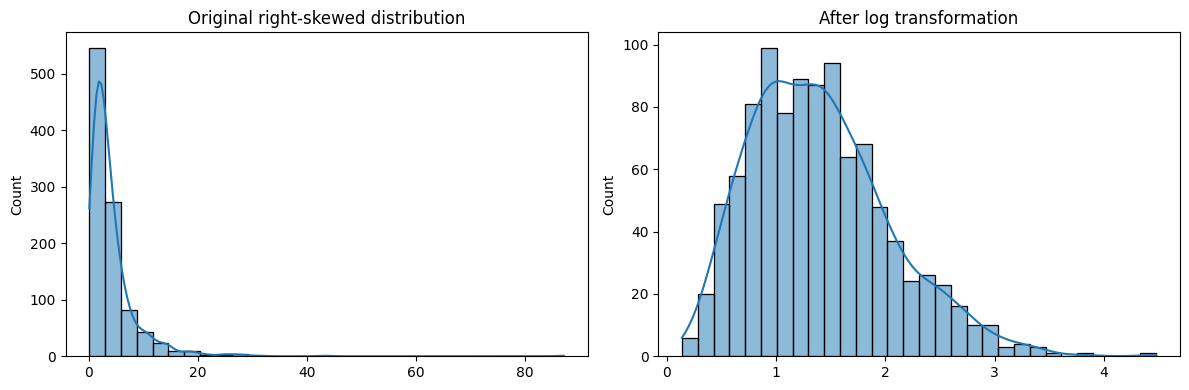

In [37]:
# Generate a strongly right-skewed distribution
x_right_skewed = np.random.lognormal(mean=1.0, sigma=0.9, size=1000)

# Log transformation
x_log = np.log1p(x_right_skewed)

plot_original_vs_transformed(
    x_right_skewed,
    x_log,
    "Original right-skewed distribution",
    "After log transformation"
)

### What Do We See?

The original distribution is strongly right-skewed: many smaller values appear together with a few very large ones.

After the logarithmic transformation:

- the large values become more compressed,
- the distribution becomes less stretched out,
- and it usually moves closer to a more symmetric shape.

This is why the logarithm can be especially useful for prices, revenues, sizes, or other positive variables with strong skewness.

## 2. Mildly Right-Skewed Distribution and Square-Root Transformation

If a distribution is right-skewed but the skewness is not too strong, then the **square-root transformation** may often be sufficient.

The square root:

- compresses the values to a smaller extent than the logarithm,
- therefore represents a milder correction,
- and can be useful when we do not want to compress the variable too aggressively.

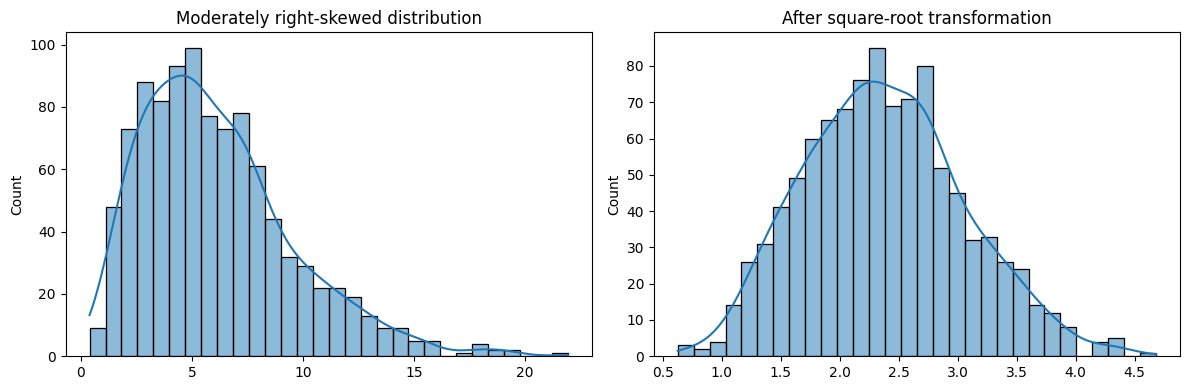

In [38]:
# Moderately right-skewed distribution
x_mild_right = np.random.gamma(shape=3, scale=2, size=1000)

# Square-root transformation
x_sqrt = np.sqrt(x_mild_right)

plot_original_vs_transformed(
    x_mild_right,
    x_sqrt,
    "Moderately right-skewed distribution",
    "After square-root transformation"
)

### What Do We See?

The original distribution is right-skewed, but not as extreme as in the previous example.

After the square-root transformation:

- the right tail appears shorter,
- the distribution becomes more balanced,
- but the transformation is less aggressive than the logarithm.

That is why the square root is often a good choice for milder right skewness.

## 3. Left-Skewed Distribution and Squaring Transformation

In a left-skewed distribution, most values are concentrated in the higher range, and the tail extends toward the left.

In some cases, a transformation that spreads out the larger values more strongly can help.  
One simple option is **squaring**.

It is important to note that this is not a universal solution, but it is a good illustration of how a transformation can also change the shape of a distribution in the opposite direction.

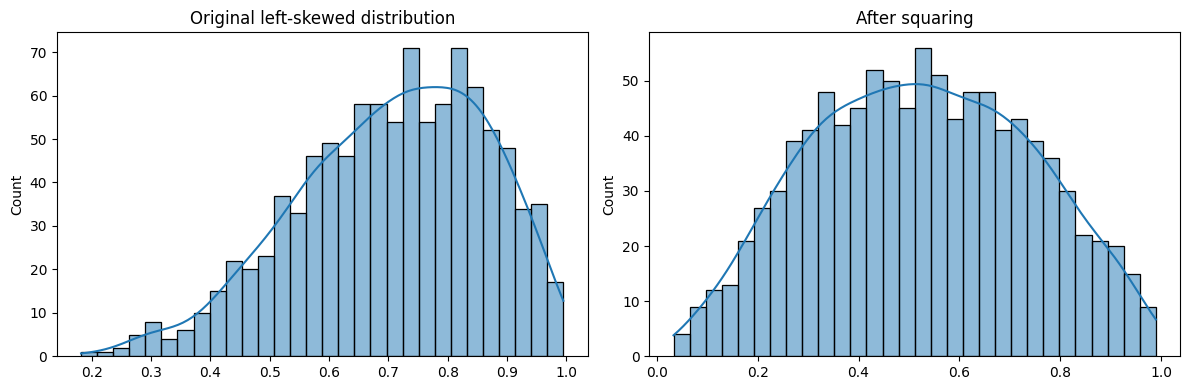

In [39]:
# Generate a left-skewed distribution between 0 and 1
x_left_skewed = np.random.beta(a=5, b=2, size=1000)

# Squaring transformation
x_squared = x_left_skewed ** 2

plot_original_vs_transformed(
    x_left_skewed,
    x_squared,
    "Original left-skewed distribution",
    "After squaring"
)

### What Do We See?

The original distribution is left-skewed: most observations are concentrated around higher values, while a tail stretches toward smaller values.

After squaring:

- the smaller values separate more clearly,
- the differences among the larger values may also become more pronounced,
- and the shape of the distribution changes.

This example shows that a transformation can do more than "compress" values; in some cases it can also "spread them out."

## 4. Left-Skewed Distribution and an Exponential-Type Transformation

An exponential transformation separates larger values more strongly, so in some cases it can help pull out a left-skewed distribution.

This is not the most common classical normalization method, but for teaching purposes it is a good illustration of how different transformations can affect the shape of a distribution in very different ways.

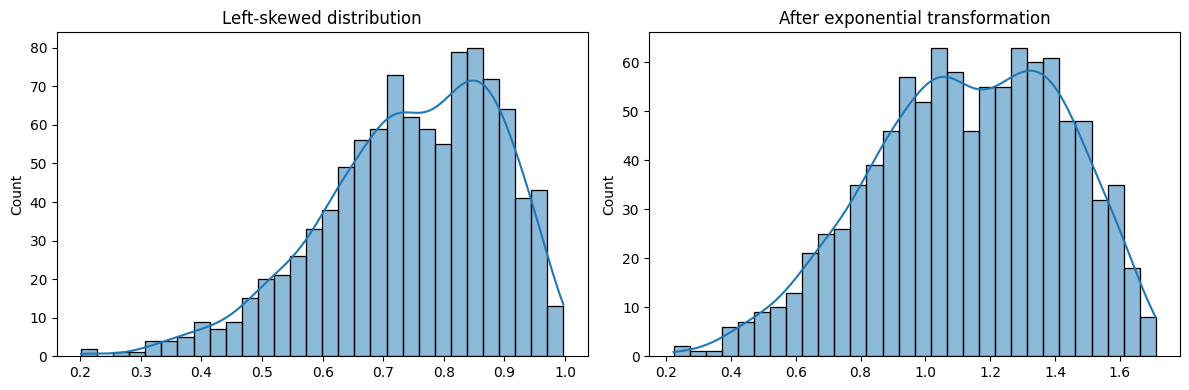

In [40]:
# The same left-skewed distribution
x_left_skewed_2 = np.random.beta(a=6, b=2, size=1000)

# Exponential-type transformation
x_exp = np.exp(x_left_skewed_2) - 1

plot_original_vs_transformed(
    x_left_skewed_2,
    x_exp,
    "Left-skewed distribution",
    "After exponential transformation"
)

### What Do We See?

The exponential transformation:

- spreads out the larger values more strongly,
- makes differences in the upper range more pronounced,
- and substantially changes the shape of the distribution.

This transformation is mainly useful for illustration, because it clearly shows that not every transformation reduces skewness in the same way: some compress values, while others spread out certain ranges.

## Examining the Effect of Transformations Numerically

We can compare how much the shape of the distribution changed not only visually, but also by using the **skewness** value.

In [47]:
summary_df = pd.DataFrame({
    "variable": [
        "x_right_skewed",
        "log(x_right_skewed)",
        "x_mild_right",
        "sqrt(x_mild_right)",
        "x_left_skewed",
        "x_left_skewed^2",
        "x_left_skewed_2",
        "exp(x_left_skewed_2)-1"
    ],
    "skewness": [
        pd.Series(x_right_skewed).skew(),
        pd.Series(x_log).skew(),
        pd.Series(x_mild_right).skew(),
        pd.Series(x_sqrt).skew(),
        pd.Series(x_left_skewed).skew(),
        pd.Series(x_squared).skew(),
        pd.Series(x_left_skewed_2).skew(),
        pd.Series(x_exp).skew()
    ]
})

summary_df

,variable,skewness
0,x_right_skewed,6.470435
1,log(x_right_skewed),0.735263
2,x_mild_right,1.020133
3,sqrt(x_mild_right),0.274911
4,x_left_skewed,-0.470450
5,x_left_skewed^2,0.018116
6,x_left_skewed_2,-0.656571
7,exp(x_left_skewed_2)-1,-0.322659


## Summary

The examples clearly show that different transformations affect the shape of a distribution in different ways.

General observations:

- **logarithm**: often very useful for strongly right-skewed distributions,
- **square root**: can be a good choice for milder right skewness,
- **squaring**: may improve the shape of some left-skewed distributions,
- **exponential transformation**: mainly useful for illustration because it shows how larger values can be spread out.

It is important to emphasize that there is no single "best" transformation for every situation.  
The appropriate choice always depends on the distribution of the given variable and on the goal of the analysis.

In the next step, we apply the same idea to real data, for example to the numerical variables of the Diamonds dataset.

## When Can Each Transformation Be Useful?

As a practical rule of thumb:

- **strongly right-skewed distribution** -> often `log(x)` or `log1p(x)`
- **mildly right-skewed distribution** -> often `sqrt(x)`
- **left-skewed distribution** -> sometimes squaring or another transformation that spreads out larger values can help
- **very different scales or special cases** -> it is worth trying several options and comparing them visually

The goal is usually not to force a perfectly normal distribution, but to create a more manageable and balanced variable.

## The Same Data with a Different Mathematical Mapping

A transformation does not create new data; it describes the same values in a different mathematical form.

This is not scaling in the traditional sense, because it can change not only the magnitude but also the shape of the distribution.

For example, a log transformation compresses large values more strongly, so a skewed distribution often becomes more balanced.

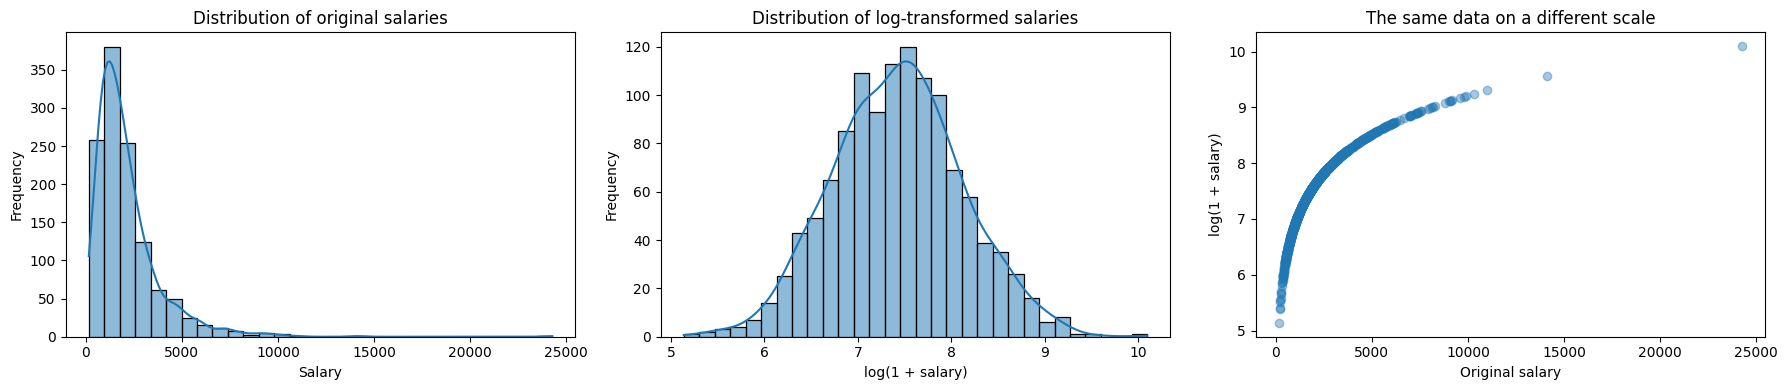

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Generate artificial salaries
# Many people earn relatively less, and only a few people earn very high amounts
salary = np.random.lognormal(mean=7.4, sigma=0.7, size=1200)

# Log transformation
salary_log = np.log1p(salary)

# Visualization: original distribution, transformed distribution, and the relationship between them
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Original distribution
sns.histplot(salary, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of original salaries")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Frequency")

# 2. Log-transformed distribution
sns.histplot(salary_log, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of log-transformed salaries")
axes[1].set_xlabel("log(1 + salary)")
axes[1].set_ylabel("Frequency")

# 3. The same data on a different scale
axes[2].scatter(salary, salary_log, alpha=0.4)
axes[2].set_title("The same data on a different scale")
axes[2].set_xlabel("Original salary")
axes[2].set_ylabel("log(1 + salary)")

plt.tight_layout()
plt.show()

## What Do We See?

The left plot shows the distribution of the original salaries.  
It is easy to observe that many smaller values appear together with a few very large salaries, so the distribution is strongly right-skewed.

The middle plot shows the logarithmically transformed version of the same variable.  
Here the distribution appears much more balanced because the large values no longer stretch the scale as much.

The right plot shows that the transformation did not create new data; it simply placed the same values on a different scale.

There is less compression among the smaller values and stronger compression among the larger ones.  
That is why the data become easier to visualize and easier to handle in many analytical situations.

## Important Note

The goal of a transformation is not to get "nicer numbers," but to make the structure of the data easier to see and work with.

Large values still remain larger than small ones, and small values still remain smaller.  
Only the shape of the distribution changes in a way that is easier to visualize, analyze, and in some cases more favorable for certain models.

## Automatic Search for a Transformation: Box-Cox

In the previous examples, we manually tried different transformations, such as the logarithm or the square root.

In practice, however, we do not always want to decide by hand which transformation is most appropriate for a given variable.  
For this, we can use the **Box-Cox transformation**, which automatically searches for a power transformation that can make the distribution more symmetric.

The key idea behind Box-Cox is that it does not try only one predefined form, but chooses from an entire family of transformations.

This is especially useful when:
- the distribution is strongly right-skewed,
- it is not obvious whether a logarithm or another transformation would be better,
- and we want to prepare the data more effectively for analysis or modeling.

Important note:

**Box-Cox can only be applied to strictly positive values**, so if a column contains 0 or negative values, we must handle that first or choose another method.

In [43]:
from scipy.stats import boxcox
# Remove missing values
price = df["price"].dropna()

# Check the minimum value
price.min()

60

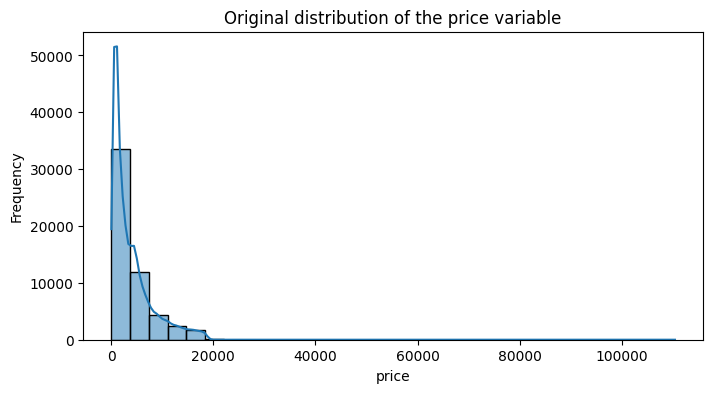

In [48]:
# Plot the original distribution
plt.figure(figsize=(8, 4))
sns.histplot(price, bins=30, kde=True)
plt.title("Original distribution of the price variable")
plt.xlabel("price")
plt.ylabel("Frequency")
plt.show()


In [45]:
# Apply the Box-Cox transformation
# The function returns two things:
# 1. the transformed data
# 2. the optimal lambda parameter
price_boxcox, best_lambda = boxcox(price)

best_lambda

np.float64(-0.06166805979376352)

## What Does the Lambda Parameter Mean?

The Box-Cox transformation uses a parameterized family of transformations whose central element is the **lambda** parameter.

The value of lambda determines what kind of transformation the method chooses:

- if lambda is close to **1**, then almost no change happens,
- if lambda is close to **0**, then the transformation is logarithm-like,
- other values correspond to other types of power transformations.

In other words, Box-Cox automatically tries to find the transformation that may be the most favorable for the given data.

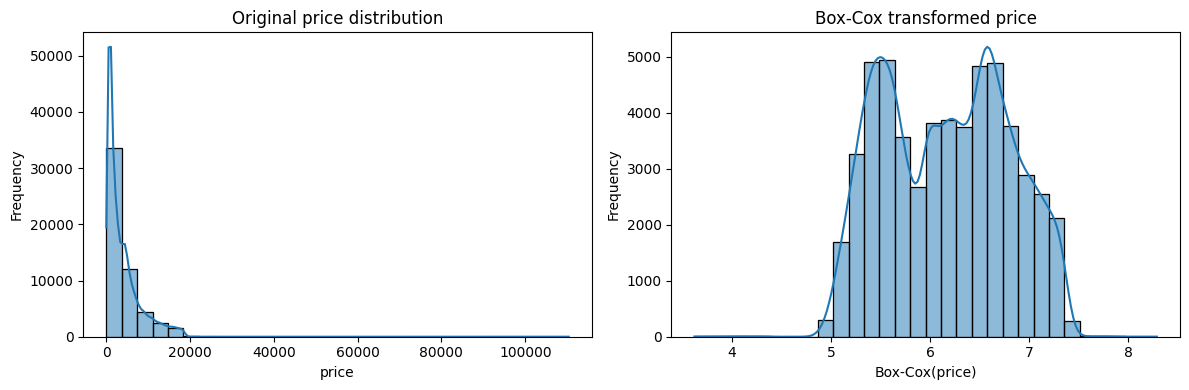

In [46]:
# Compare the original and the Box-Cox transformed distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(price, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original price distribution")
axes[0].set_xlabel("price")
axes[0].set_ylabel("Frequency")

sns.histplot(price_boxcox, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Box-Cox transformed price")
axes[1].set_xlabel("Box-Cox(price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## What Do We See After the Transformation?

After the Box-Cox transformation, the distribution generally:

- becomes less right-skewed,
- becomes more balanced,
- and often moves closer to a more symmetric shape.

The skewness value also shows this numerically.  
If the transformation worked well, then the absolute value of skewness decreases.

This means that the data:
- are easier to visualize,
- are often easier to analyze,
- and may become more suitable for certain models.

## Exercises

## Exercise 1 - Comparing Logarithm and Box-Cox

For the `price` variable, we have already seen that the Box-Cox transformation can reduce skewness.

Now compare the following three versions of the `price` variable:

- original `price`
- logarithmically transformed `price`
- Box-Cox transformed `price`

### Task:
1. Create the logarithmically transformed version of `price` using
`np.log1p()`.
2. Plot the three distributions side by side in histograms.
3. Compute the skewness value for all three versions.
4. Decide which of the three appears to be the most symmetric.

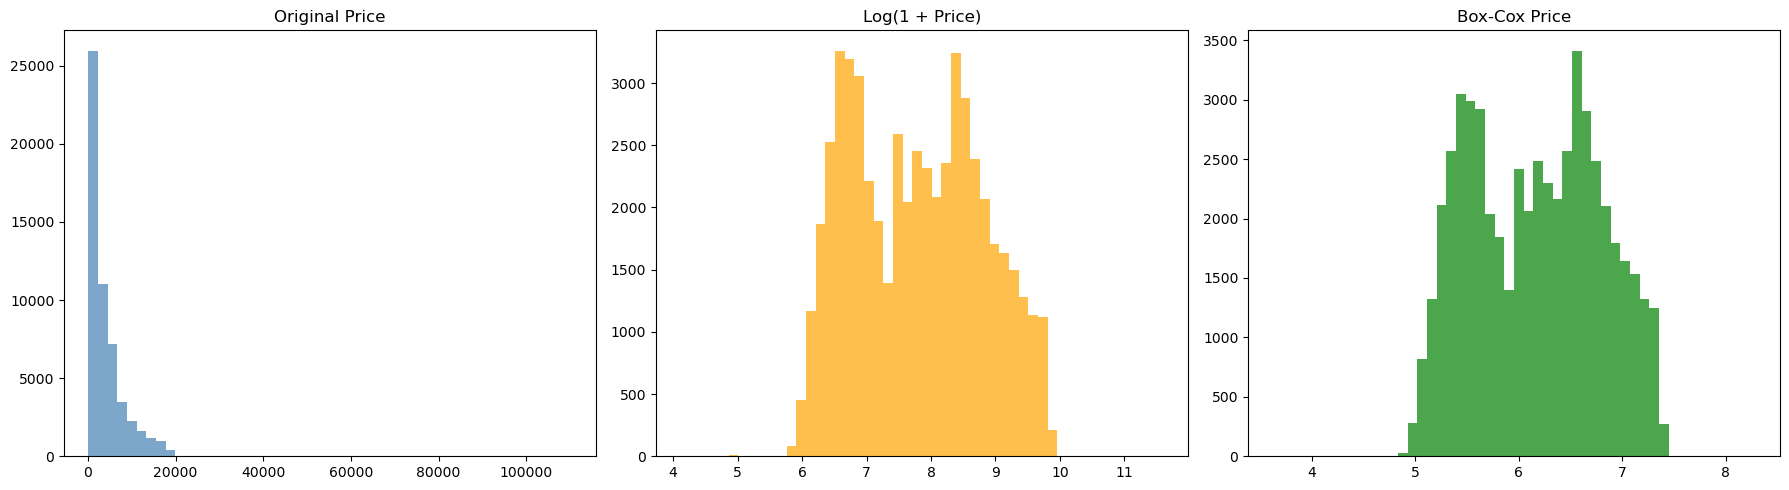

Skewness values:
Original: 2.4587854888745104
Log1p: 0.11111544186931673
Box-Cox: 0.022434331214747888


In [9]:
import numpy as np
from scipy.stats import skew
import pandas as pd
import json
import urllib.request

csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

df = pd.read_csv(csv_url)

# Original price
price_orig = df["price"]

# Log transform (log1p handles zeros safely)
price_log = np.log1p(price_orig)

# Box-Cox transform (requires positive values)
from scipy.stats import boxcox

price_boxcox, _ = boxcox(price_orig[price_orig > 0])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(price_orig, bins=50, color="steelblue", alpha=0.7)
axes[0].set_title("Original Price")

axes[1].hist(price_log, bins=50, color="orange", alpha=0.7)
axes[1].set_title("Log(1 + Price)")

axes[2].hist(price_boxcox, bins=50, color="green", alpha=0.7)
axes[2].set_title("Box-Cox Price")

plt.tight_layout()
plt.show()


skew_orig = skew(price_orig.dropna())
skew_log = skew(price_log.dropna())
skew_boxcox = skew(price_boxcox)

print("Skewness values:")
print("Original:", skew_orig)
print("Log1p:", skew_log)
print("Box-Cox:", skew_boxcox)

## Exercise 2 - Comparing Skewness Values in a Table

In the previous exercise, you examined the three versions of the `price` variable one by one.

Now create a short summary table that contains:

- the name of the version,
- its skewness value.

### Task:
Create a `DataFrame` with the following rows:
- `original`
- `log`
- `Box-Cox`

Based on the table, summarize your observation in 1-2 sentences.

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import skew, boxcox

# Original
price_orig = df["price"]

# Log transform
price_log = np.log1p(price_orig)

# Box-Cox (only positive values)
price_boxcox, _ = boxcox(price_orig[price_orig > 0])

# Skewness values
skew_orig = skew(price_orig.dropna())
skew_log = skew(price_log.dropna())
skew_boxcox = skew(price_boxcox)


skew_table = pd.DataFrame({
    "transformation": ["original", "log", "Box-Cox"],
    "skewness": [skew_orig, skew_log, skew_boxcox]
})

skew_table

,transformation,skewness
0,original,2.458785
1,log,0.111115
2,Box-Cox,0.022434


## Exercise 3 - Trying Box-Cox on Another Numerical Variable

After `price`, choose another numerical variable from the Diamonds dataset, for example:

- `carat`
- `depth`
- `table`
- `x`
- `y`
- `z`

### Task:
1. Select one numerical column.
2. Check whether all values in the column are positive.
3. Plot the original distribution.
4. Apply the Box-Cox transformation.
5. Plot the original and transformed distributions side by side.
6. Compare the skewness values.

### Question:
- Did Box-Cox work just as well for this variable as it did for price?

Any zero or negative values? True


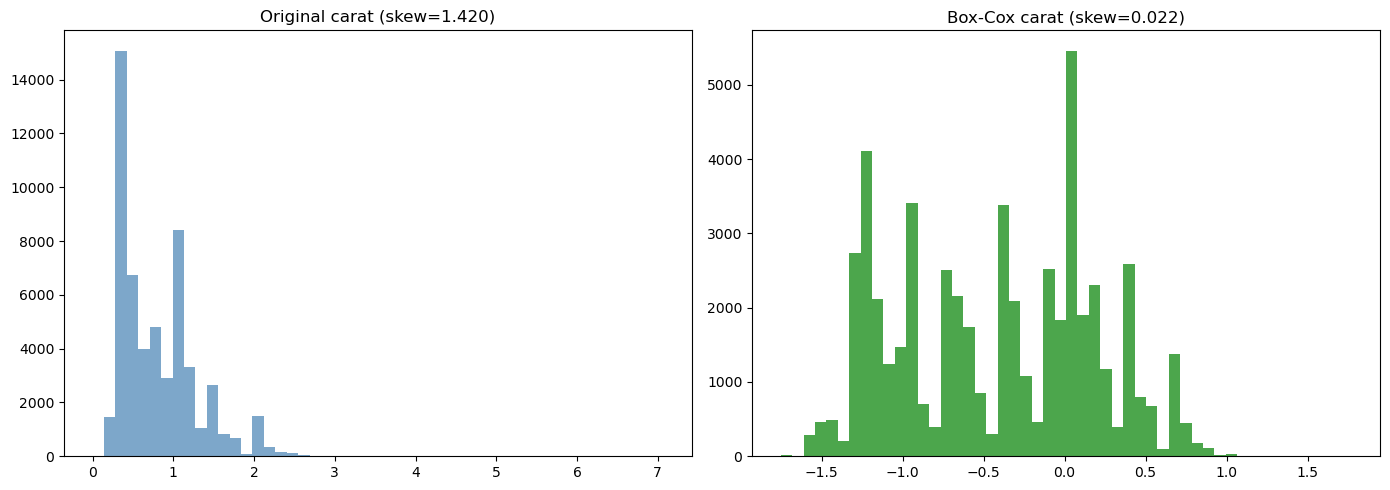

Skewness comparison:
Original: 1.419948301582521
Box-Cox: 0.02194931517255448
Lambda: -0.10387160122154307


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, boxcox

col = "carat" 

# Clean data
data_all = df[col].dropna()

print("Any zero or negative values?", (data_all <= 0).any())

data = data_all[data_all > 0]


# Skewness (original)
skew_orig = skew(data_all)


# Box-Cox transformation
data_boxcox, lambda_bc = boxcox(data)

skew_boxcox = skew(data_boxcox)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_all, bins=50, color="steelblue", alpha=0.7)
axes[0].set_title(f"Original {col} (skew={skew_orig:.3f})")

axes[1].hist(data_boxcox, bins=50, color="green", alpha=0.7)
axes[1].set_title(f"Box-Cox {col} (skew={skew_boxcox:.3f})")

plt.tight_layout()
plt.show()


print("Skewness comparison:")
print("Original:", skew_orig)
print("Box-Cox:", skew_boxcox)
print("Lambda:", lambda_bc)

## Exercise 4 - Examining Multiple Numerical Columns at Once

We do not have to examine only a single variable; we can also go through all numerical columns.

### Task:
1. Select the numerical columns of the dataset.
2. Keep only those that:
   - are not empty,
   - and contain only positive values.
3. For each such column, compute:
   - the original skewness value,
   - the skewness value after Box-Cox,
   - the Box-Cox lambda parameter.
4. Organize the results into a table.

### Think about:
- Which column was originally the most skewed?
- For which one did skewness improve the most?
- Was there any column where the change was barely noticeable?

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import skew, boxcox


num_cols = df.select_dtypes(include=[np.number]).columns

results = []


for col in num_cols:
    data_all = df[col].dropna()

    # skip empty columns
    if len(data_all) == 0:
        continue

    # check positivity requirement
    if (data_all <= 0).any():
        continue

    try:
        # original skewness
        skew_orig = skew(data_all)

        # Box-Cox transformation
        data_bc, lam = boxcox(data_all)

        # transformed skewness
        skew_bc = skew(data_bc)

        # store results
        results.append({
            "column": col,
            "skew_original": skew_orig,
            "skew_boxcox": skew_bc,
            "lambda": lam,
            "abs_improvement": abs(skew_orig) - abs(skew_bc)
        })

    except Exception as e:
        # skip problematic columns safely
        continue


results_df = pd.DataFrame(results)

# sort by strongest improvement
results_df = results_df.sort_values("abs_improvement", ascending=False)

results_df

,column,skew_original,skew_boxcox,lambda,abs_improvement
2,price,2.458785,0.022434,-0.061668,2.436351
1,table,0.908973,-0.050248,-4.096977,0.858725
0,depth,-0.096998,0.102894,1.534869,-0.005896
